In [ ]:
import numpy as np
import pygritbx as pgt
print(pgt.__version__)

1.1.4


In [3]:
i = np.array([1, 0, 0])
j = np.array([0, 1, 0])
k = np.array([0, 0, 1])
RF = np.array([i, j, k])

In [4]:
# Input Motor
input_motor = pgt.Motor(name="Input Motor", power=6e3, n=2750, axis=+k)

In [5]:
print(input_motor.ETs[0].torque)

[ 0.          0.         20.83482891]


In [6]:
# Gear Material Properties
R1R4_material = pgt.Material(name='Steel', sigma_u=1060, sigma_y=950, HB=335)
R2R3_material = pgt.Material(name='Steel', sigma_u=1950, sigma_y=1400, HB=560)

In [7]:
# Shaft A1 Components' Locations
a1 = 46.75 # [mm]
b1 = 43.5 # [mm]

zA = 0 # [mm]
zB = a1
zR1 = a1 + b1 # [mm]

In [8]:
# Spindle P Components' Locations
zR2 = 0 # [mm]
zR3 = 55 # [mm]

In [9]:
# Shaft A2 Components' Locations
a2 = 23.75 # [mm]
b2 = 58 # [mm]
c2 = 77.5 # [mm]

zR4 = 26 # [mm]
zC = zR4 + a2
zD = zC + b2
zOut = zD + c2 # [mm]

In [10]:
# Gears
# R1
R1 = pgt.Gear(name="R1", loc=zR1, axis=k, m_n=2.5, z=18, psi=20, phi_n=20, Q_v=7, FW=30, material=R1R4_material)
# R2
R2 = pgt.Gear(name="R2", loc=zR2, axis=k, m_n=2.5, z=73, psi=-20, phi_n=20, Q_v=7, FW=30, material=R2R3_material)
# R3
R3 = pgt.Gear(name="R3", loc=zR3, axis=k, m_n=2.5, z=19, psi=20, phi_n=20, Q_v=7, FW=30, material=R2R3_material)
# R4
R4 = pgt.Gear(name="R4", loc=zR4, axis=k, m_n=2.5, z=51, psi=-20, phi_n=20, Q_v=7, FW=30, material=R1R4_material)

In [11]:
# Supports
# A (roller 30203)
A = pgt.Support(name="A", type="Roller", bearingType="Tapered", catalogueName="30203", 
                catalogueType="Explorer", d=17, D=40, B=13.25, C=23.4e3, C0=18.6e3, Pu=1.83e3, 
                nr=15e3, a=9, e=0.35, X=0, Y=1.7, Y0=0.9, Y1=0, Y2=0, A=0, kr=0, shoulder=-1, 
                arr="B2B", axis=k, loc=zA)

# B (roller 30203)
B = pgt.Support(name="B", type="Pin", bearingType="Tapered", catalogueName="30203", 
                catalogueType="Explorer", d=17, D=40, B=13.25, C=23.4e3, C0=18.6e3, Pu=1.83e3, 
                nr=15e3, a=9, e=0.35, X=0, Y=1.7,Y0=0.9, Y1=0, Y2=0, A=0, kr=0, shoulder=1,
                arr="B2B", axis=k, loc=zB)

# C (roller 30208)
C = pgt.Support(name="C", type="Roller", bearingType="Tapered", catalogueName="30208", 
                catalogueType="Explorer", d=40, D=80, B=19.75, C=75.8e3, C0=68e3, Pu=7.65e3, 
                nr=7e3, a=16, e=0.37, X=0, Y=1.6, Y0=0.9, Y1=0, Y2=0, A=0, kr=0, shoulder=-1, 
                arr="B2B", axis=k, loc=zC)

# D (roller 30208)
D = pgt.Support(name="D", type="Pin", bearingType="Tapered", catalogueName="30208", 
                catalogueType="Explorer", d=40, D=80, B=19.75, C=75.8e3, C0=68e3, Pu=7.65e3, 
                nr=7e3, a=16, e=0.37, X=0, Y=1.6, Y0=0.9, Y1=0, Y2=0, A=0, kr=0, shoulder=1, 
                arr="B2B", axis=k, loc=zD)

# F
F = pgt.Support(axis=k) # Generic bearing for the spindle. Characteristics are irrelevant.

In [12]:
# Output Component
output = pgt.Component(name="Output", axis=k, loc=zOut)

In [13]:
# Shaft A1 definition
A1 = pgt.Shaft(name="A1", inputs=[input_motor], outputs=[R1], sups=np.array([A, B]), axis=k, 
               loc=[0, 0, 0])

In [14]:
# Mesh M1 definition
M1 = pgt.GearMesh(name="M1", drivingGear=R1, drivenGear=R2, radiality=[-j], type="External")

In [15]:
# Spindle P definition
spindleP = pgt.Shaft(name="P", inputs=[R2], outputs=[R3], sups=np.array([F, F]), axis=k)

In [16]:
# Mesh M2 definition
M2 = pgt.GearMesh(name="M2", drivingGear=R3, drivenGear=R4, radiality=[j], type="External")

In [17]:
shaftMaterial = pgt.Material(name='34NiCrMo6', sigma_u=1050, sigma_y=950, sigma_Dm1=520)

In [18]:
A2 = pgt.Shaft(name="A2", inputs=[R4], outputs=[output], sups=np.array([C, D]), axis=k, 
              material=shaftMaterial)

In [19]:
# Solving for shaft A1
A1.solve()

Checking torque equilibrium for A1.
A1 does not mainatain a torque equilibrium.
Checking solvability for A1.
Solving torque equilibrium for A1.
Torque equilibrium for A1 is solved.
Checking torque equilibrium for R1.
R1 does not mainatain a torque equilibrium.
Checking solvability for R1.
Solving forces on R1 due to mesh M1.
Checking torque equilibrium for R1.
R1 mainatains a torque equilibrium.
Checking force equilibrium on A1.
A1 does not maintain a force equilibrium.
Axial reaction forces on A1 with Tapered bearings: Case 1a
Checking force equilibrium on A1.
A1 maintains a force equilibrium.


In [20]:
# Reaction Forces on Bearing A
print(A.F_tot.force)

[-809.65663399  475.8122391  -865.57152262]


In [21]:
# Reaction Forces on Bearing B
print(B.F_tot.force)

# output
# [1679.80485557 -812.84590846  548.86347056]

[1679.80485557 -812.84590846  548.86347056]


In [22]:
# Solving for Gear R2
R2.solve()

Checking torque equilibrium for R2.
Checking solvability for R2.
Solving torque equilibrium for R2.
Checking torque equilibrium for R2.
R2 mainatains a torque equilibrium.


In [23]:
# Solving for Spindle P
spindleP.solve()

Checking torque equilibrium for P.
P does not mainatain a torque equilibrium.
Checking solvability for P.
Solving torque equilibrium for P.
Torque equilibrium for P is solved.
Checking torque equilibrium for R3.
R3 does not mainatain a torque equilibrium.
Checking solvability for R3.
Solving forces on R3 due to mesh M2.
Checking torque equilibrium for R3.
R3 mainatains a torque equilibrium.
Checking force equilibrium on P.
P does not maintain a force equilibrium.
Reaction forces on P won't be calculated.


In [24]:
# Solving for Gear R4
R4.solve()

Checking torque equilibrium for R4.
Checking solvability for R4.
Solving torque equilibrium for R4.
Checking torque equilibrium for R4.
R4 mainatains a torque equilibrium.


In [25]:
R4.EFs[0].force

array([ 3343.20106188,  1294.91883492, -1216.82567369])

In [26]:
# Calculating the Forces on Output User
Fout_r = np.abs(np.sum(R4.ETs[0].torque)) / 0.1 * j
Fout_a = 0.25 * np.abs(np.sum(Fout_r)) * (-k)
Fout = pgt.Force(force=Fout_a+Fout_r, loc=output.abs_loc)
A2.outputs[0].updateEFs([Fout])

In [27]:
# Solving for Shaft A2
A2.solve()

Checking torque equilibrium for A2.
A2 does not mainatain a torque equilibrium.
Checking solvability for A2.
Solving torque equilibrium for A2.
Torque equilibrium for A2 is solved.
Checking force equilibrium on A2.
A2 does not maintain a force equilibrium.
Axial reaction forces on A2 with Tapered bearings: Case 2a
Checking force equilibrium on A2.
A2 maintains a force equilibrium.


In [28]:
# Reaction Forces on Bearing C
print(C.F_tot.force)

# output
# [-4712.18425533  -217.84651183 -1474.13035668]

[-4712.18425533  -217.84651183 -1474.13035668]


In [29]:
# Reaction Forces on Bearing D
print(D.F_tot.force)

# output
# [ 1368.98319344 -3345.14448819  3257.97407164]

[ 1368.98319344 -3345.14448819  3257.97407164]


In [30]:
radii=np.array([33, 35,    35, 40,    40,  34,    34,    32,   32,  31]) / 2 
alocs=np.array([ 0,  1,  45.9, 46, 132.9, 133, 158.4, 158.5,  222, 223])

In [31]:
trial = pgt.ShaftProfile(name="trial", radii=radii, locs=alocs)

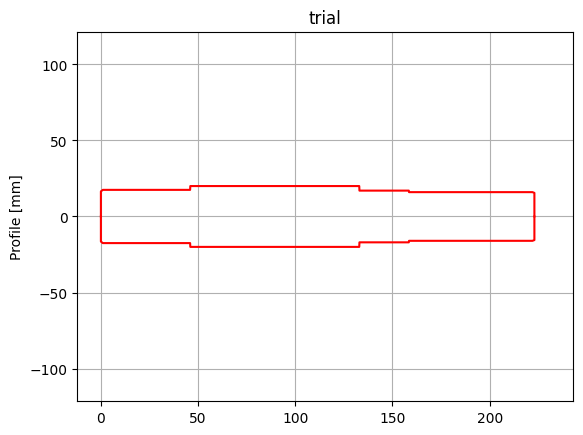

In [32]:
trial.plotProfile()

In [33]:
static_radii = np.array([33, 35,   35, 30,   30, 35,   35, 40,    40,  34,    34,    32,    32,    27,    27,    32,  32,  31]) / 2
static_alocs = np.array([ 0,  1, 11.9, 12, 39.9, 40, 45.9, 46, 132.9, 133, 158.4, 158.5, 178.4, 178.5, 208.4, 208.5, 222, 223])

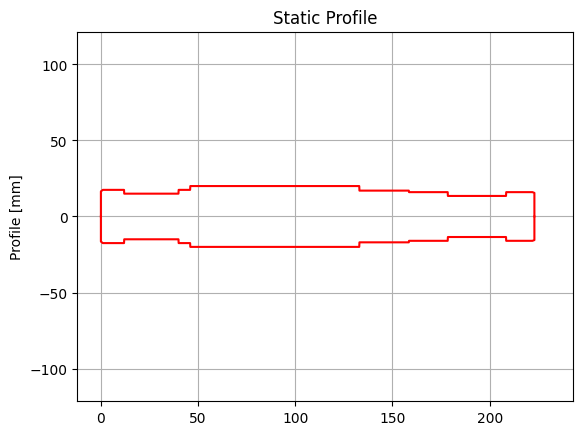

In [34]:
# Define a Shaft Profile for Static Verification
static_profile = pgt.ShaftProfile(name="Static Profile", radii=static_radii, locs=static_alocs)

# Plot Defined Profile
static_profile.plotProfile()

In [35]:
# Refine Static Profile
static_profile_refined = static_profile.refineProfile(delta=0.1)

In [36]:
# Add First Fillet to Static Profile
static_profile_refined.addFillet(radius=1, quadrant=[2], zOff=45, dOff=18.5)

In [37]:
# Add Second Fillet to Static Profile
static_profile_refined.addFillet(radius=1, quadrant=[1], zOff=134, dOff=18)

In [38]:
# Add Static Profile to Shaft A2
A2.addProfile(profile=static_profile_refined)

In [39]:
# Section V1 Definition
V1 = pgt.ShaftSection(name="V1", loc=26, d=30, Ra=0.8, material=shaftMaterial)

In [40]:
# Section V1 Stress Concentration Raiser
V1.appendKf(Kf=np.array([1.6, 2.0]), loadType=np.array(["Bending", "Torsion"]))

In [41]:
# Section V2 Definition
V2 = pgt.ShaftSection(name="V2", loc=46, d=40, Ra=0.8, material=shaftMaterial)

In [42]:
# Section V2 Notch Sensitivity and Geometric Stress Rasier
V2.addNotchSensitivity(notchRadius=1, sigma_u=shaftMaterial.sigma_u)
V2.addGeometricStressRaiser(r2d=1/35, D2d=40/35)

In [43]:
# Section V3 Definition
V3 = pgt.ShaftSection(name="V3", loc=133, d=40, Ra=0.8, material=shaftMaterial)

# Section V3 Notch Sensitivity and Geometric Stress Raiser
V3.addNotchSensitivity(notchRadius=1, sigma_u=shaftMaterial.sigma_u)
V3.addGeometricStressRaiser(r2d=1/34, D2d=40/34)

In [44]:
# Add Sections to Shaft A2
userSections = np.array([V1, V2, V3])
A2.addSections(sections=userSections)

Initiating static verification on shaft A2.
Calculating internal loads on shaft A2.


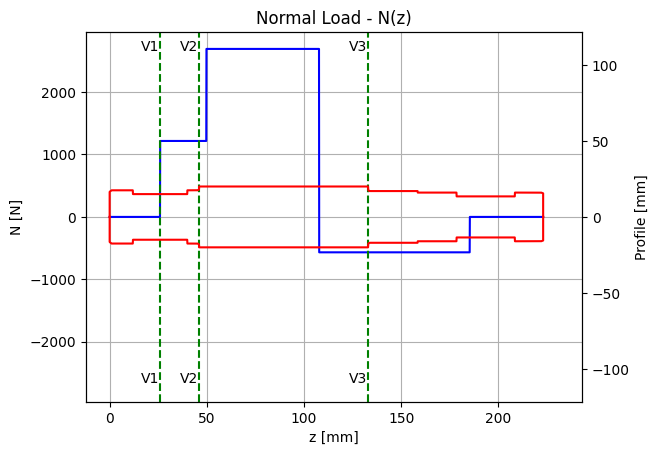

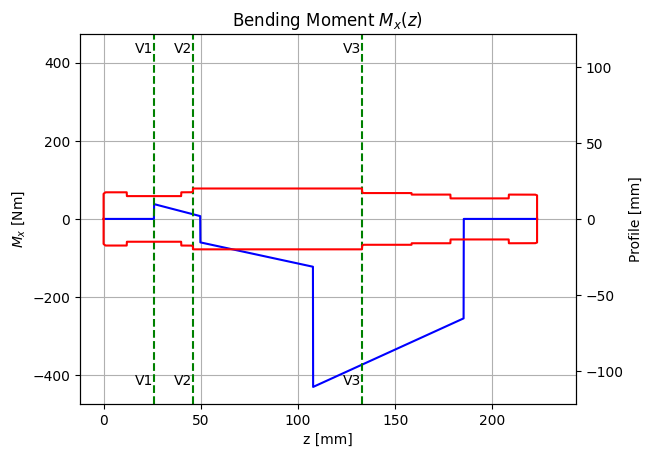

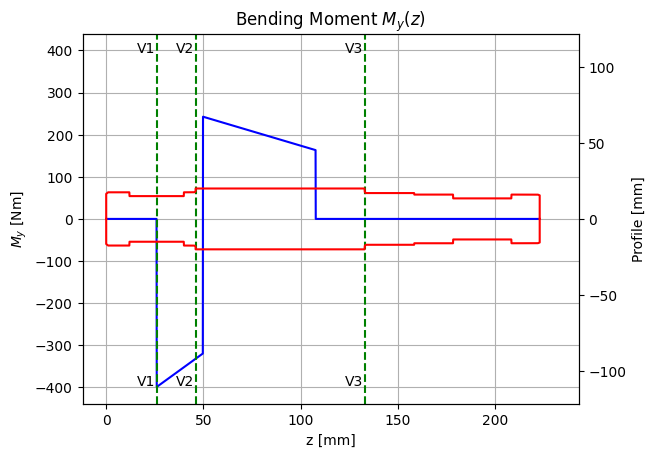

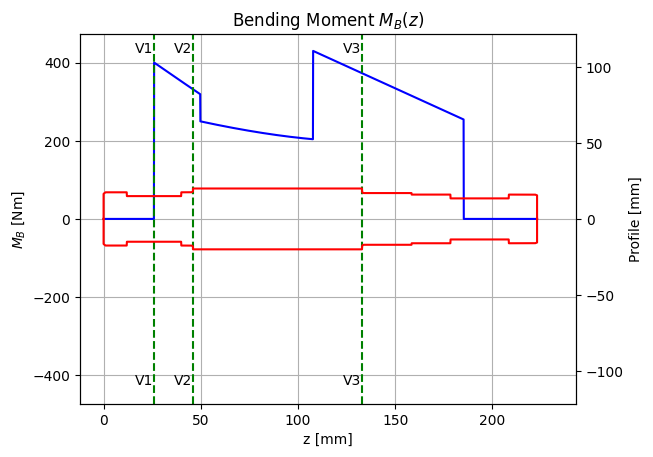

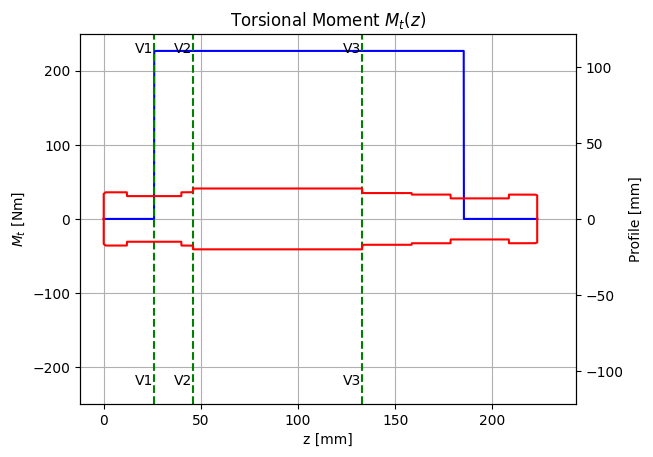

Calculating stresses on shaft A2 along profile 'Static Profile'.


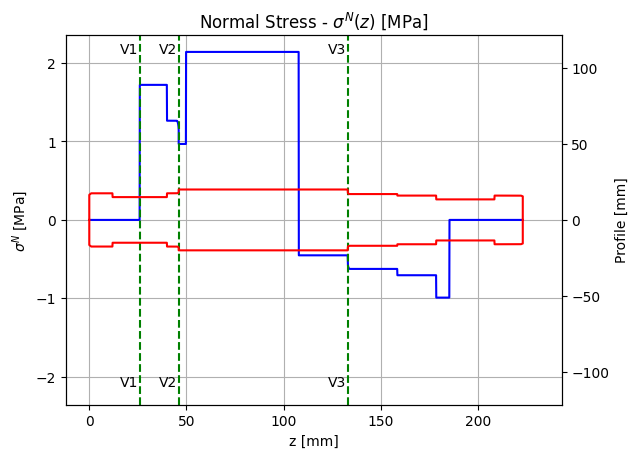

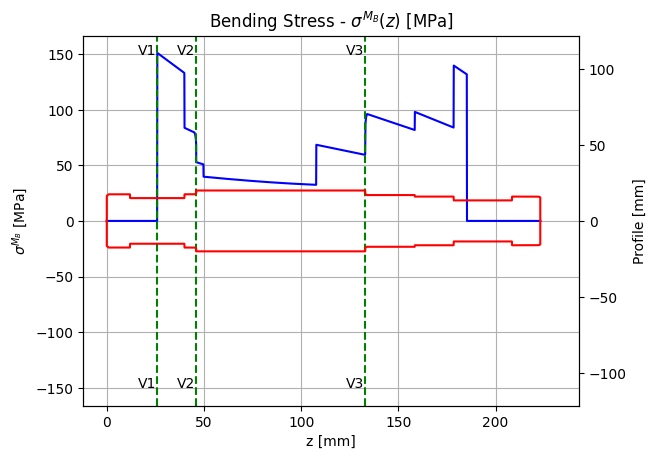

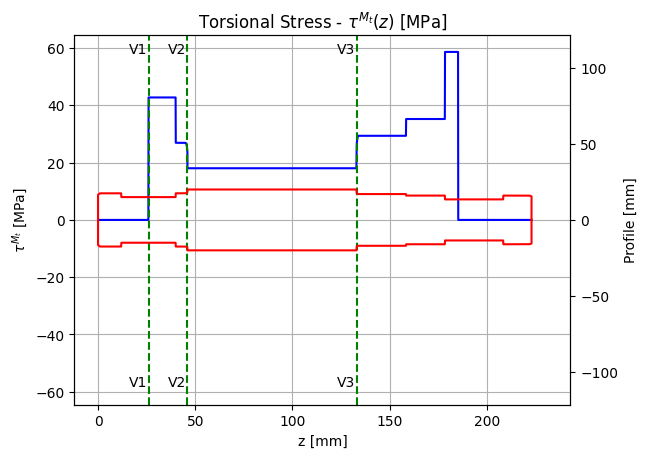

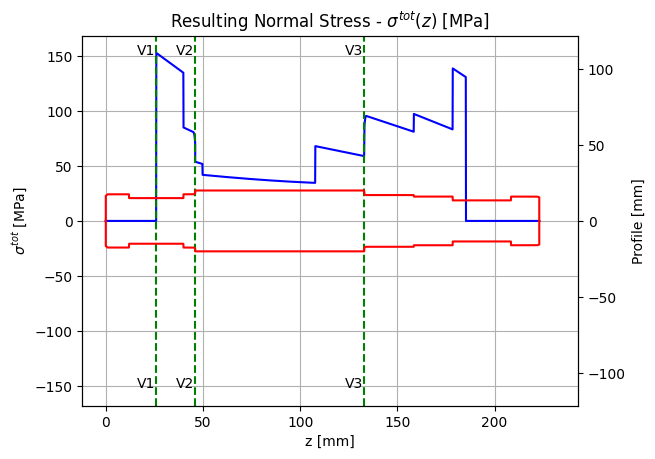

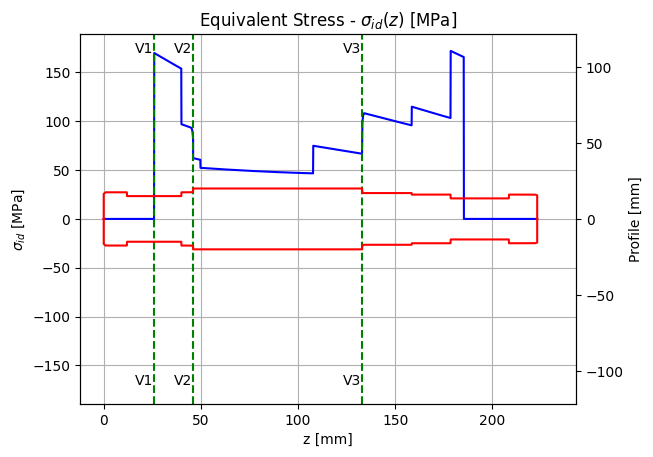

Calculating static safety factor for every user-defined section.
Section Name: Static Safety Factor
Section V1: 5.59 [-].
Section V2: 15.27 [-].
Section V3: 10.37 [-].


In [45]:
# Perform Static Verification on Shaft A2
A2.performStaticVerification(RF=RF, profile=A2.profiles[0])

In [46]:
# Define Radii and Axial Locations
radii = np.array([33, 35,    35, 40,    40,  34,    34,    32,   32,  31]) / 2 
alocs = np.array([ 0,  1,  45.9, 46, 132.9, 133, 158.4, 158.5,  222, 223])

# Define a Shaft Profile for Fatigue Verification
fatigue_profile = pgt.ShaftProfile(name="Fatigue Profile", radii=radii, locs=alocs)

# Refine Fatigue Profile
fatigue_profile_refined = fatigue_profile.refineProfile(delta=0.1)

# Add First Fillet to Fatigue Profile
fatigue_profile_refined.addFillet(radius=1, quadrant=[2], zOff=45, dOff=18.5)

# Add Second Fillet to Fatigue Profile
fatigue_profile_refined.addFillet(radius=1, quadrant=[1], zOff=134, dOff=18)

# Add Fatigue Profile to Shaft A2
A2.addProfile(profile=fatigue_profile_refined)

# Modify Diameter for First Section Accordingly
A2.sections[0].d = 35
userSections[0].d = 35

Initiating fatigue verification on shaft A2.
Internal loads for shaft A2 already calculated.
Calculating stresses on shaft A2 along profile 'Fatigue Profile'.


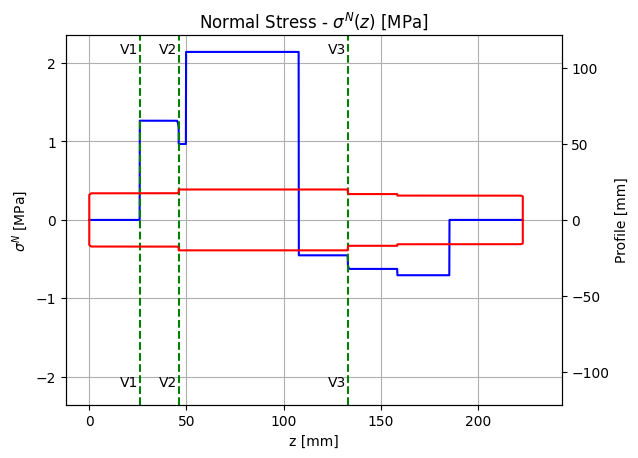

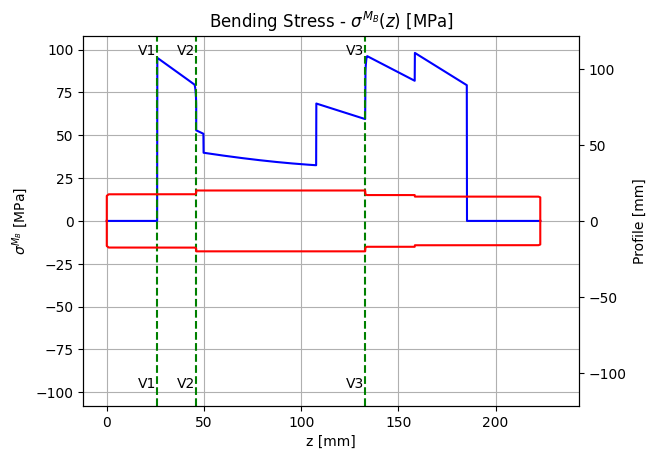

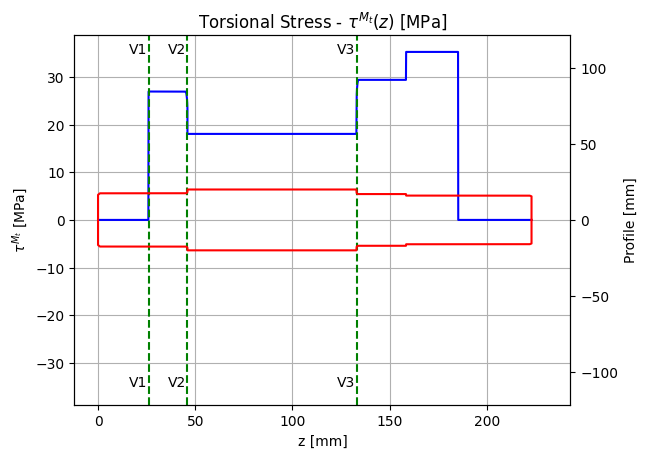

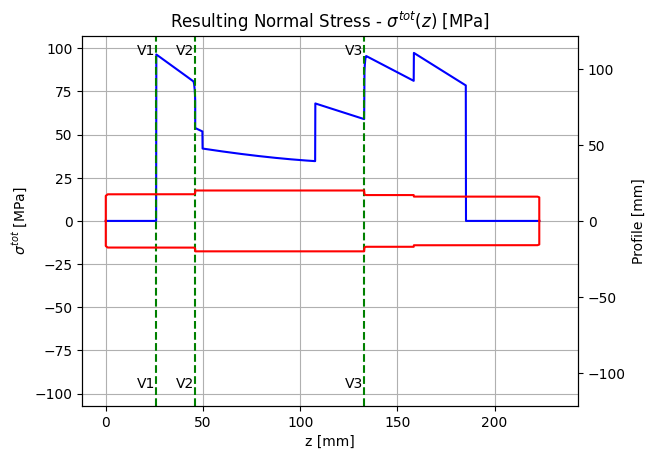

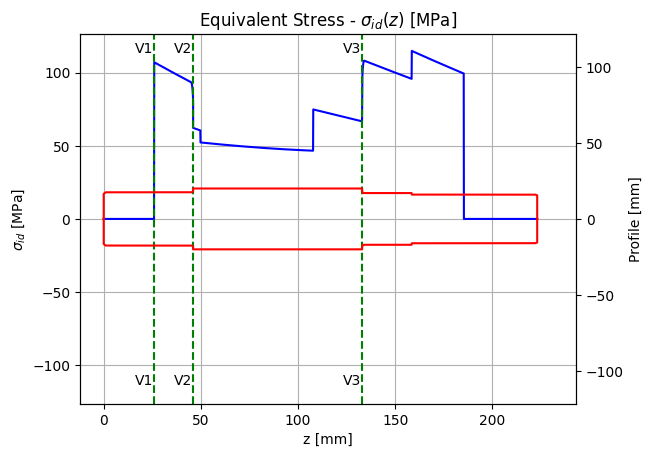

Calculating mean and alternating stresses for every user-defined section.
Calculating fatigue limit corrector factors on every user-defined section.
Calculating equivalent mean and alternating stresses along every user-defined section.


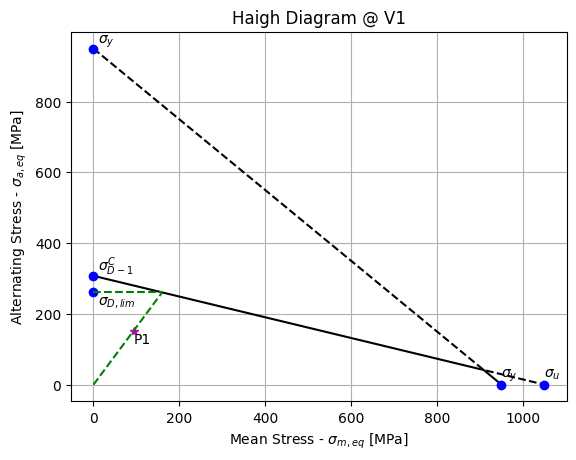

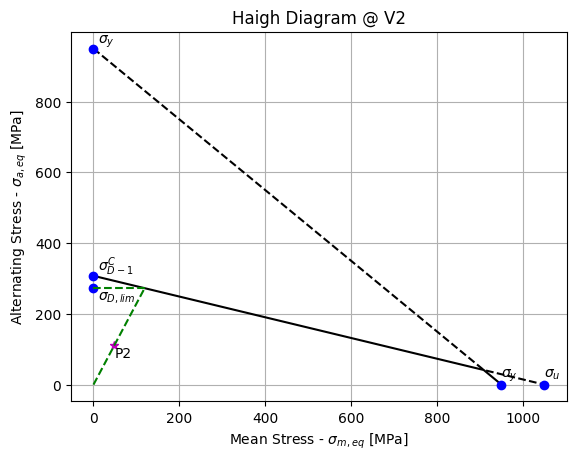

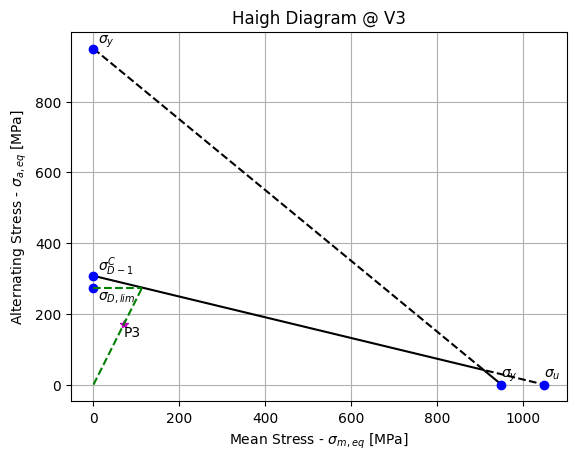

Calculating fatigue safety factor for every user-defined section.
Section Name: Fatigue Safety Factor
Section V1: 1.71 [-].
Section V2: 2.46 [-].
Section V3: 1.60 [-].


In [47]:
# Perform Fatigue Verification on Shaft A2
A2.performFatigueVerification(RF=RF, profile=A2.profiles[1])

In [66]:
# Section V1: Alternating and Mean Stress
# Normal Stress
print(f"Mean Normal Stress: {V1.sigma_m_N:.2f} [MPa]")
print(f"Alternating Normal Stress: {V1.sigma_a_N:.2f} [MPa]")

# Output
# Mean Normal Stress: 1.26 [MPa]
# Alternating Normal Stress: 0.0 [MPa]

# Bending Stress
print(f"Mean Bending Stress: {V1.sigma_m_Mb:.2f} [MPa]")
print(f"Alternating Bending Stress: {V1.sigma_a_Mb:.2f} [MPa]")

# Output
# Mean Bending Stress: 0.0 [MPa]
# Alternating Bending Stress: 95.1 [MPa]

# Torsional Stress
print(f"Mean Torsional Stress: {V1.tau_m_Mt:.2f} [MPa]")
print(f"Alternating Torsional Stress: {V1.tau_a_Mt:.2f} [MPa]")

# Output
# Mean Torsional Stress: 26.9 [MPa]
# Alternating Torsional Stress: 0.0 [MPa]

Mean Normal Stress: 1.26 [MPa]
Alternating Normal Stress: 0.00 [MPa]
Mean Bending Stress: 0.00 [MPa]
Alternating Bending Stress: 95.14 [MPa]
Mean Torsional Stress: 26.94 [MPa]
Alternating Torsional Stress: 0.00 [MPa]


In [ ]:
# Section V2: Stress Concentration Factors
# Notch Sensitivity
print(f"Notch Sensitivity: {V2.q.qReq:.2f} [-]")

# Output
# Notch Sensitivity: 0.88 [-]

# Normal Stress Concentration Factor and Raiser
print(f"Normal Stress Concentration Factor: {V2.Kt_N:.2f} [-]")
print(f"Normal Stress Concentration Raiser: {V2.Kf_N:.2f} [-]")

# Output
# Normal Stress Concentration Factor: 2.24 [-]
# Normal Stress Concentration Raiser: 2.1 [-]

# Bending Stress Concentration Factor and Raiser
print(f"Bending Stress Concentration Factor: {V2.Kt_B:.2f} [-]")
print(f"Bending Stress Concentration Raiser: {V2.Kf_B:.2f} [-]")

# Output
# Bending Stress Concentration Factor: 2.25 [-]
# Bending Stress Concentration Raiser: 2.1 [-]

# Torsional Stress Concentration Factor and Raiser
print(f"Torsional Stress Concentration Factor: {V2.Kt_T:.2f} [-]")
print(f"Torsional Stress Concentration Raiser: {V2.Kf_T:.2f} [-]")

# Output
# Torsional Stress Concentration Factor: 1.62 [-]
# Torsional Stress Concentration Raiser: 1.55 [-]

Notch Sensitivity: 0.88 [-]
Normal Stress Concentration Factor: 2.24 [-]
Normal Stress Concentration Raiser: 2.1 [-]
Bending Stress Concentration Factor: 2.25 [-]
Bending Stress Concentration Raiser: 2.1 [-]
Torsional Stress Concentration Factor: 1.62 [-]
Torsional Stress Concentration Raiser: 1.55 [-]


In [ ]:
# Section V3: Fatigue Limit Correction Factors
# Size Effect
print(f"C_s = {V3.FLCF.Cs_req:.2f} [-]")

# Output
# C_s = 0.84 [-]

# Surface Finish Effect
print(f"C_f = {V3.FLCF.Cf_req:.2f} [-]")

# Output
# C_f = 1.0 [-]

C_s = 0.84 [-]
C_f = 1.00 [-]


In [ ]:
# Fatigue Limit Correction on Shaft A2
print(f"Corrected Fatigue Limit: {A2.material.sigma_Dm1C:.2f} [MPa]")

# Output
# Corrected Fatigue Limit: 307.58 [MPa]

Corrected Fatigue Limit: 307.58 [MPa]


In [52]:
# Gear R1: Gear Tooth Bending Safety Factor
R1.analyseGearToothBending(mesh=M1, powerSource="Uniform", drivenMachine="Uniform", dShaft=35, Ce=1, teethCond="uncrowned teeth",
                           lShaft=a1+b1, useCond="Commercial, enclosed units", sigma_FP=320, b_YN=1.3558, e_YN=-0.0178,
                           N=1e8, temp=60, rel=0.99)

Initiating gear tooth bending analysis for gear R1.
Calculating maximum gear tooth bending stress for fatigue.
Maximum gear tooth bending stress for fatigue for gear R1: 88.16 [MPa].
Calculating bending safety factor for gear R1.
Gear tooth bending safety factor for gear R1: 3.55 [-].


In [70]:
# Print Calculated Factors
# Overload Factor
print(f"Overload factor: {R1.K_0:.2f}")

# Output: Overload factor: 1.00

#----------------------------------------------------------

# Rim-Thickness Factor
print(f"Rim-Thickness Factors: {R1.K_B:.2f}")

# Output: Rim-Thickness Factors: 2.14

#----------------------------------------------------------

# Dynamic Factor
print(f"Dynamic Factor: {R1.K_v:.2f}")

# Output: Dynamic Factor: 1.54

#----------------------------------------------------------

# Load Distribution Factor
print(f"Load Distribution Factor: {R1.K_H:.2f}")

# Output: Load Distribution Factor: 1.19

#----------------------------------------------------------

# Size Factor
print(f"Size Factor: {R1.K_S:.2f}")

# Output: Size Factor: 1.03

#----------------------------------------------------------

# Bending Strength Geometry Factor
print(f"Geometry Factor J': {R1.J_p:.2f}")
print(f"Geometry Factor J'': {R1.J_pp:.2f}")
print(f"Bending Strength Geometry Factor Y_J: {R1.Y_J:.2f}")

# Output:
# Geometry Factor J': 0.53
# Geometry Factor J'': 0.95
# Bending Strength Geometry Factor J': 0.50

#----------------------------------------------------------

# Stress Cycle Life Factor
print(f"Stress Cycle Life Factor: {R1.Y_N:.2f}")

# Output: Stress Cycle Life Factor: 0.98

#----------------------------------------------------------

# Temperature Factor
print(f"Temperature Factor: {R1.Y_theta:.2f}")

# Output: Temperature Factor: 1.00

#----------------------------------------------------------

# Reliability Factor
print(f"Reliability Factor: {R1.Y_Z:.2f}")

# Output: Reliability Factor: 1.00

Overload factor: 1.00
Rim-Thickness Factors: 2.14
Dynamic Factor: 1.54
Load Distribution Factor: 1.19
Size Factor: 1.03
Geometry Factor J': 0.53
Geometry Factor J'': 0.95
Bending Strength Geometry Factor Y_J: 0.50
Stress Cycle Life Factor: 0.98
Temperature Factor: 1.00
Reliability Factor: 1.00


In [54]:
# Gear R3: Gear Tooth Bending Safety Factor
R3.analyseGearToothBending(mesh=M2, powerSource="Uniform", drivenMachine="Uniform", dShaft=30, Ce=1, teethCond="uncrowned teeth",
                           lShaft=70, useCond="Commercial, enclosed units", sigma_FP=450, b_YN=1.3558, e_YN=-0.0178,
                           N=1e8, temp=60, rel=0.99)

Initiating gear tooth bending analysis for gear R3.
Calculating maximum gear tooth bending stress for fatigue.
Maximum gear tooth bending stress for fatigue for gear R3: 131.62 [MPa].
Calculating bending safety factor for gear R3.
Gear tooth bending safety factor for gear R3: 3.34 [-].


In [55]:
# Gear R1: Gear Tooth Wear Safety Factor
R1.analyseGearToothPitting(mesh=M1, Z_R=1, sigma_HP=860, b_ZN=1.4488, e_ZN=-0.023, N=1e8)

Initiating gear tooth pitting analysis for gear R1.
Calculating maximum gear contact stress.
Maximum gear contact stress for gear R1: 316.39 [MPa].
Calculating wear safety fator for gear R1.
Wear safety factor for gear R1: 2.58 [-].


In [56]:
# Gear R3: Gear Tooth Wear Safety Factor
R3.analyseGearToothPitting(mesh=M2, Z_R=1, sigma_HP=1360, b_ZN=1.4488, e_ZN=-0.023, N=1e8)

Initiating gear tooth pitting analysis for gear R3.
Calculating maximum gear contact stress.
Maximum gear contact stress for gear R3: 562.66 [MPa].
Calculating wear safety fator for gear R3.
Wear safety factor for gear R3: 2.32 [-].


In [57]:
# Define oil of choice
oil = pgt.Oil(name="ISO VG 100", temp=60, v1=15, v=45)

In [ ]:
# Bearing A
# Contamination Factor
A.calculateEtaC(condition="Slight contamination")
print(f"Bearing A Contamination Factor: {A.eta_c:.2f}")

# Output: Bearing A Contamination Factor: 0.40

#-------------------------------------------------------

# Equivalent Dynamic Load
A.calculateEquivalentDynamicLoad()
print(f"Bearing A Equivalent Dynamic Load: {A.P:.2f} [N]")

# Output: Bearing A Equivalent Dynamic Load: 1635.01 [N]

#-------------------------------------------------------

# Oil Viscosity Ratio
print(f"Oil '{oil.name}' Viscosity Ratio: {oil.k:.2f}")

# Output: Oil 'ISO VG 100' Viscosity Ratio: 3.00

Bearing A Contamination Factor: 0.40
Bearing A Equivalent Dynamic Load: 1635.01 [N]
Oil 'ISO VG 100' Viscosity Ratio: 3.00


In [64]:
# Bearing A: Life Analysis
A.performLifeAnalysis(rel=95, condition="Slight contamination", a_skf=2, oil=oil)

Initiating Life Analysis on bearing A.
Checking minimum load condition.
Bearing A satisfies minimium load condition.
Calculating static safety factor.
Bearing A's equivalent static load: 3219.33 [N].
Bearing A's static safety factor: 5.78 [-].
Calculating reliability factor.
Bearing A's reliability factor: 0.64 [-].
Calculating equivalent dynamic load.
Bearing A's equivalent dynamic load: 1635.01 [N].
Calculating contamination factor based on given condition: 'Slight contamination'.
Bearing A's contamination factor: 0.40 [-].
Calculating bearing life.
Bearing A life analysis results: 9110.13 [million cycles] | 55212.92 [hours].
